# 04 — Shower-particle 4-vectors (first look)

This notebook inspects the **full Geant4 shower cascade** of a single electromagnetic
event: one 50 GeV photon fired into the silicon-tungsten ECal barrel along +y.

Unlike the main pipeline (which keeps only the primary particle and reconstructs a
single energy), here we persist the 4-vector of **every** secondary produced in the
shower — the eventual input to a high-fidelity silicon pixel simulation (PIXELAV).

**How the data was produced** (`sim/run_sim_fullcascade.py`):
- single `gamma`, 50 GeV, +y pencil beam, `FTFP_BERT` physics
- `part.keepAllParticles = True` **and** `part.userParticleHandler = ""` — the latter
  is essential: DDSim's default `Geant4TCUserParticleHandler` restricts MC-truth to the
  inner tracking region, which would merge away calorimeter-shower secondaries.
- DD4hep **native** ROOT output (`outputConfig.forceDD4HEP`) — a workaround for an
  EDM4hep-output crash in this Key4hep build (see `docs/troubleshooting.md`).

The cascade was then extracted to a compact `.npz` (`analysis`/`extract_cascade.py`
pattern) so this notebook needs only numpy + matplotlib.

**Units:** momenta / energies / masses in GeV, positions / vertices in mm.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Locate the extracted cascade archive (works whether run from notebooks/ or repo root)
_cands = [
    os.path.join(os.environ.get("CALOMAPS_HOME", ""), "models", "fullcascade_gamma50_1evt.npz"),
    os.path.join("..", "models", "fullcascade_gamma50_1evt.npz"),
    os.path.join("models", "fullcascade_gamma50_1evt.npz"),
]
NPZ = next((p for p in _cands if p and os.path.exists(p)), None)
if NPZ is None:
    raise FileNotFoundError(
        "Cascade .npz not found in " + str(_cands) +
        " — run analysis/extract_cascade.py first.")
d = np.load(NPZ, allow_pickle=True)
required = ["pdg", "mass", "E", "px", "py", "pz", "vsx", "vsy", "vsz", "hx", "hy", "hz", "he"]
missing = [k for k in required if k not in d]
if missing:
    raise KeyError(f"cascade {NPZ} is missing expected arrays: {missing}")
print("loaded:", NPZ)
print("arrays:", list(d.keys()))

pdg, mass, E = d["pdg"], d["mass"], d["E"]
px, py, pz = d["px"], d["py"], d["pz"]
vsx, vsy, vsz = d["vsx"], d["vsy"], d["vsz"]   # production vertex (mm)
hx, hy, hz, he = d["hx"], d["hy"], d["hz"], d["he"]  # hits (mm, GeV)

n = len(pdg)
print(f"\nN shower particles: {n:,}")
print(f"N silicon hits:     {len(hx):,}")
print(f"Total deposited E in Si: {he.sum():.3f} GeV  (sampling fraction ~{he.sum()/50:.2%})")
print(f"Primary (particle 0): pdg={pdg[0]}, E={E[0]:.1f} GeV, p=({px[0]:.2f},{py[0]:.1f},{pz[0]:.2f}) GeV")

loaded: /nashome/m/murtazas/CALOMAPS/models/fullcascade_gamma50_1evt.npz
arrays: ['pdg', 'mass', 'px', 'py', 'pz', 'E', 'vsx', 'vsy', 'vsz', 'vex', 'vey', 'vez', 'pid', 'parent', 'status', 'gstat', 'hx', 'hy', 'hz', 'he', 'meta']

N shower particles: 74,793
N silicon hits:     7,671
Total deposited E in Si: 0.784 GeV  (sampling fraction ~1.57%)
Primary (particle 0): pdg=22, E=50.0 GeV, p=(0.00,50.0,0.00) GeV


## 1. Particle composition

An EM shower is dominated by electrons, positrons and photons (pair production +
bremsstrahlung). A handful of hadrons / nuclei appear from photonuclear interactions
in the tungsten absorber.

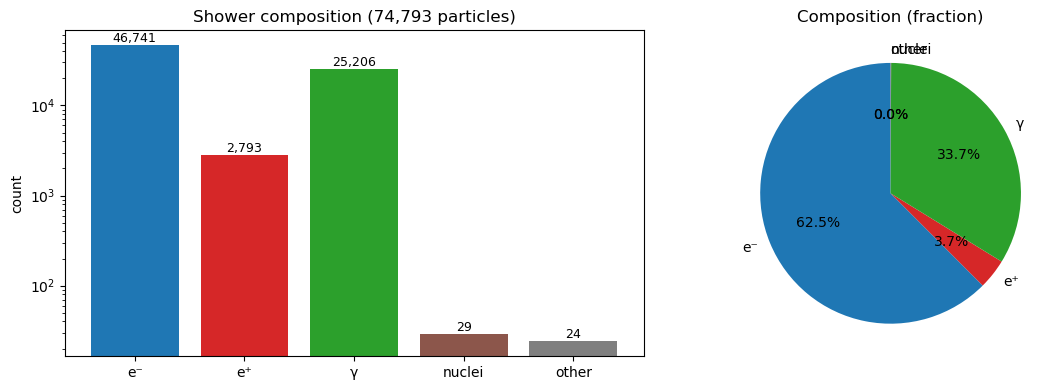

top PDG codes: [(11, 46741), (22, 25206), (-11, 2793), (2112, 20), (1000741840, 6), (1000741860, 6), (1000741820, 4), (2212, 4)]


In [2]:
labels = {22: "γ (photon)", 11: "e⁻", -11: "e⁺", 2112: "neutron", 2212: "proton"}
uniq, counts = np.unique(pdg, return_counts=True)
order = np.argsort(-counts)

# Group: e-, e+, gamma, nuclei (|pdg|>1e9), other
groups = {"e⁻": 0, "e⁺": 0, "γ": 0, "nuclei": 0, "other": 0}
for p, c in zip(uniq, counts):
    if p == 11: groups["e⁻"] += c
    elif p == -11: groups["e⁺"] += c
    elif p == 22: groups["γ"] += c
    elif abs(p) > 1_000_000_000: groups["nuclei"] += c
    else: groups["other"] += c

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
g = {k: v for k, v in groups.items() if v}
ax[0].bar(g.keys(), g.values(), color=["#1f77b4", "#d62728", "#2ca02c", "#8c564b", "#7f7f7f"][:len(g)])
ax[0].set_yscale("log"); ax[0].set_ylabel("count"); ax[0].set_title(f"Shower composition ({n:,} particles)")
for i, (k, v) in enumerate(g.items()):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

ax[1].pie(list(g.values()), labels=list(g.keys()), autopct="%1.1f%%", startangle=90,
          colors=["#1f77b4", "#d62728", "#2ca02c", "#8c564b", "#7f7f7f"][:len(g)])
ax[1].set_title("Composition (fraction)")
plt.tight_layout(); plt.show()
print("top PDG codes:", [(int(uniq[i]), int(counts[i])) for i in order[:8]])

## 2. Energy spectrum

The shower is overwhelmingly **soft** — a steeply falling spectrum of low-energy
secondaries, with a few high-energy particles near the top of the cascade (the primary
and the first conversion e±). Nuclei are excluded here (their "energy" is dominated by
GeV-scale rest mass, not kinematics).

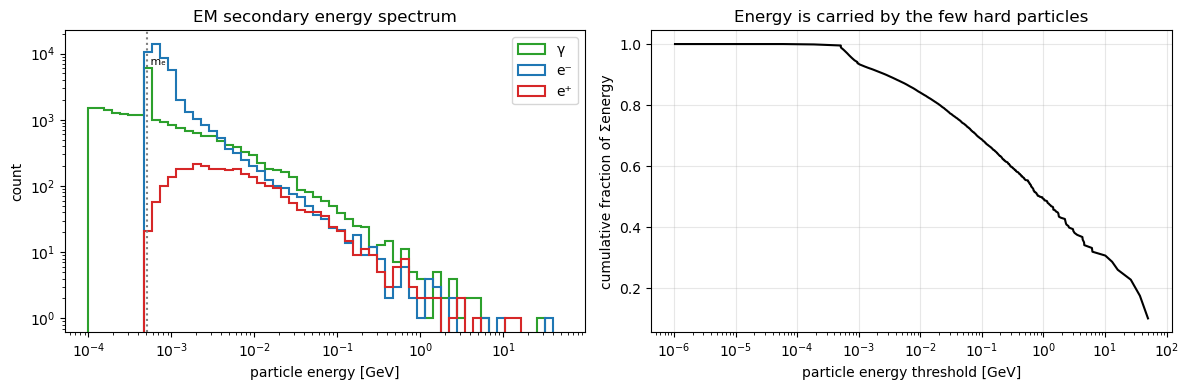

median EM particle energy: 0.69 MeV
# EM particles above 1 GeV: 46 (0.06%)


In [3]:
em = (pdg == 11) | (pdg == -11) | (pdg == 22)
Eem = E[em]
Eem = Eem[Eem > 0]
assert Eem.size, "no EM (e/gamma) particles with E>0 in this event — energy-spectrum plot needs them"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bins = np.logspace(np.log10(max(Eem.min(), 1e-4)), np.log10(Eem.max()), 60)
for sel, lab, col in [(pdg == 22, "γ", "#2ca02c"), (pdg == 11, "e⁻", "#1f77b4"), (pdg == -11, "e⁺", "#d62728")]:
    es = E[sel]; es = es[es > 0]
    ax[0].hist(es, bins=bins, histtype="step", label=lab, color=col, lw=1.5)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("particle energy [GeV]"); ax[0].set_ylabel("count")
ax[0].set_title("EM secondary energy spectrum"); ax[0].legend()
ax[0].axvline(0.000511, ls=":", color="grey"); ax[0].text(0.000511, ax[0].get_ylim()[1]*0.3, " mₑ", fontsize=8)

# cumulative energy carried vs particle energy
es = np.sort(Eem)[::-1]
ax[1].plot(es, np.cumsum(es)/es.sum(), color="black")
ax[1].set_xscale("log"); ax[1].set_xlabel("particle energy threshold [GeV]")
ax[1].set_ylabel("cumulative fraction of Σenergy"); ax[1].set_title("Energy is carried by the few hard particles")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"median EM particle energy: {np.median(Eem)*1000:.2f} MeV")
print(f"# EM particles above 1 GeV: {(Eem>1).sum():,} ({(Eem>1).mean():.2%})")

## 3. Longitudinal & radial shower development

The beam travels along +y from the origin; the ECal front face is at r≈1267 mm.
Production vertices show **where** secondaries are born — the classic shower buildup
and decay along depth into the calorimeter.

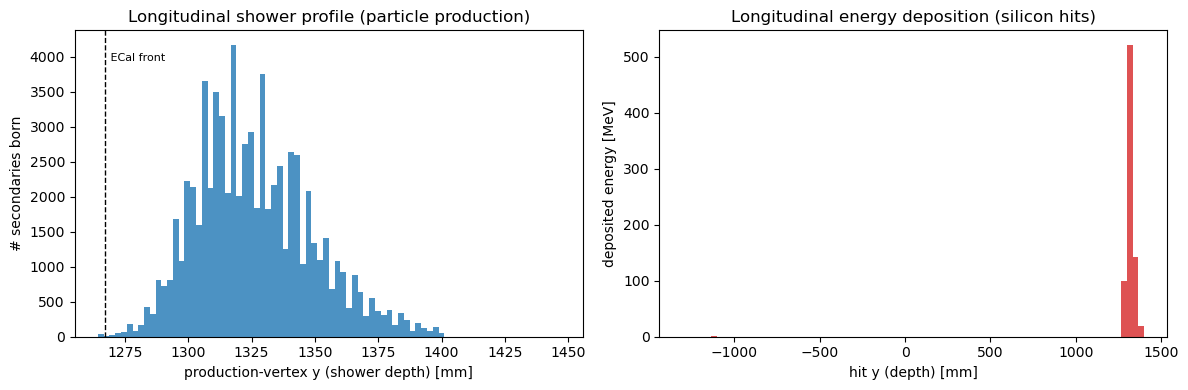

In [4]:
r_prod = np.hypot(vsx, vsy)  # but beam is along +y, so depth ~ y; use y as depth, r as transverse is x-z
# For a +y beam, "depth" into the barrel is the radial coordinate measured along y.
depth = vsy  # mm (production vertex y); shower develops in +y
sel = (depth > 1200) & (depth < 1450) & em   # within the ECal, EM particles

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(depth[sel], bins=80, color="#1f77b4", alpha=0.8)
ax[0].set_xlabel("production-vertex y (shower depth) [mm]"); ax[0].set_ylabel("# secondaries born")
ax[0].set_title("Longitudinal shower profile (particle production)")
ax[0].axvline(1267, ls="--", color="k", lw=1); ax[0].text(1268, ax[0].get_ylim()[1]*0.9, " ECal front", fontsize=8)

# energy deposited vs depth (from hits)
ax[1].hist(hy, bins=80, weights=he*1000, color="#d62728", alpha=0.8)
ax[1].set_xlabel("hit y (depth) [mm]"); ax[1].set_ylabel("deposited energy [MeV]")
ax[1].set_title("Longitudinal energy deposition (silicon hits)")
plt.tight_layout(); plt.show()

## 4. Shower shape — transverse spread and 3D view

Transverse coordinates are x and z (the beam is +y). The shower is narrow near the
front and spreads with depth. Below: hit positions colored by deposited energy.

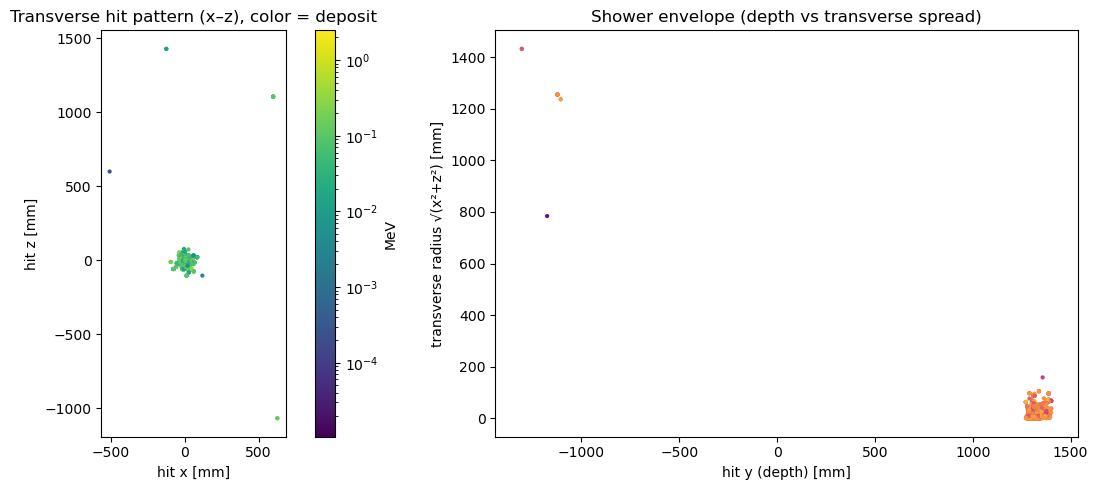

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# transverse profile: x vs z of hits, colored by energy
sc = ax[0].scatter(hx, hz, c=he*1000, s=4, cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
ax[0].set_xlabel("hit x [mm]"); ax[0].set_ylabel("hit z [mm]"); ax[0].set_aspect("equal")
ax[0].set_title("Transverse hit pattern (x–z), color = deposit"); plt.colorbar(sc, ax=ax[0], label="MeV")

# depth vs transverse radius (shower envelope): y vs sqrt(x^2+z^2) of hits
rt = np.hypot(hx, hz)
ax[1].scatter(hy, rt, c=he*1000, s=4, cmap="plasma", norm=plt.matplotlib.colors.LogNorm())
ax[1].set_xlabel("hit y (depth) [mm]"); ax[1].set_ylabel("transverse radius √(x²+z²) [mm]")
ax[1].set_title("Shower envelope (depth vs transverse spread)")
plt.tight_layout(); plt.show()

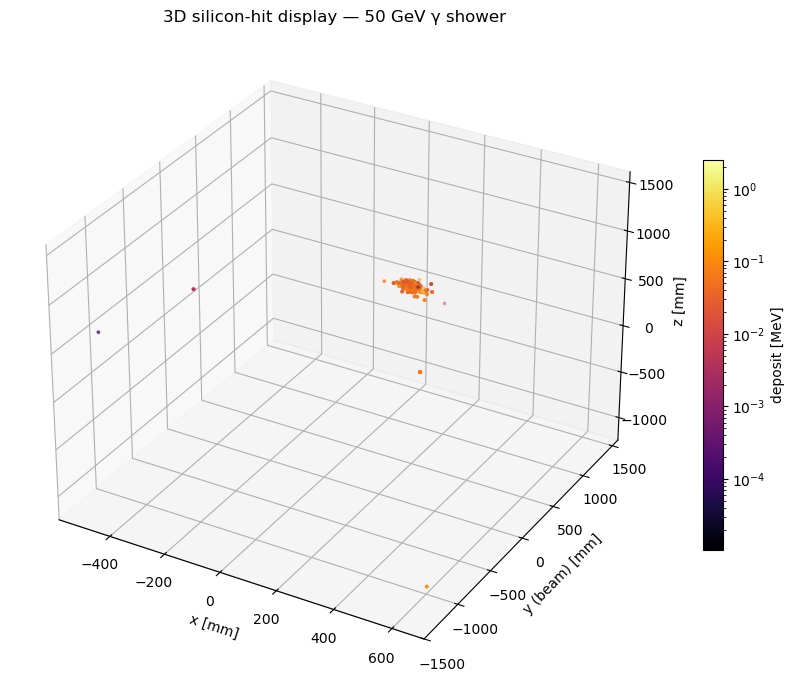

In [6]:
# 3D view of the silicon hits (the shower as it deposits in the detector)
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sub = slice(None) if len(hx) < 20000 else np.random.default_rng(0).choice(len(hx), 20000, replace=False)
p = ax.scatter(hx[sub], hy[sub], hz[sub], c=he[sub]*1000, s=3, cmap="inferno",
               norm=plt.matplotlib.colors.LogNorm())
ax.set_xlabel("x [mm]"); ax.set_ylabel("y (beam) [mm]"); ax.set_zlabel("z [mm]")
ax.set_title("3D silicon-hit display — 50 GeV γ shower")
fig.colorbar(p, label="deposit [MeV]", shrink=0.6)
plt.tight_layout(); plt.show()

## 5. Momentum directions

Secondaries are produced predominantly forward (+y, following the primary) but with a
real angular spread that grows for softer particles — this opening-angle information is
exactly what a pixel-level simulation needs per track.

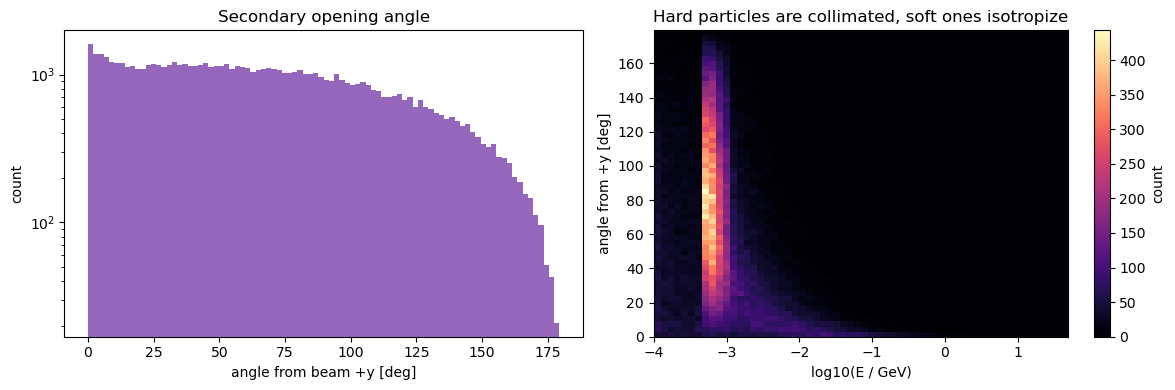

In [7]:
pmag = np.sqrt(px**2 + py**2 + pz**2)
good = (pmag > 0) & em
# angle from +y beam axis
cos_t = py[good] / pmag[good]
theta = np.degrees(np.arccos(np.clip(cos_t, -1, 1)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(theta, bins=90, color="#9467bd")
ax[0].set_xlabel("angle from beam +y [deg]"); ax[0].set_ylabel("count")
ax[0].set_title("Secondary opening angle"); ax[0].set_yscale("log")

# opening angle vs energy (hard particles stay forward)
sc = ax[1].hist2d(np.log10(np.clip(E[good], 1e-4, None)), theta, bins=[60, 60], cmap="magma")
ax[1].set_xlabel("log10(E / GeV)"); ax[1].set_ylabel("angle from +y [deg]")
ax[1].set_title("Hard particles are collimated, soft ones isotropize")
plt.colorbar(sc[3], ax=ax[1], label="count")
plt.tight_layout(); plt.show()

## Summary & next steps

- We can extract the **complete shower cascade** (74k particles for a 50 GeV γ): every
  secondary's PDG, 4-vector and production/end vertex.
- Physics checks out: pair-conversion of the primary, brem/pair cascade, correct
  W/Si sampling fraction (~1.6%), forward-peaked but spreading secondaries.

**Toward PIXELAV:** PIXELAV needs, per charged track crossing a sensor, the local
**entry/exit points, direction cosines, and momentum**. That is *per-sensor step-level*
information (experiment "B"), which is richer than the production 4-vectors shown here.
The next step is to associate the shower particles with the silicon hits they produce
(the hit truth contributions) and emit PIXELAV-format track segments. See
`analysis/pixelav_converter.py` (scaffold).